# 04 — Crisis regimes: answering the research question

> *Do the lessons of past crises carry over? Does robust dynamic asset allocation earn its value primarily in crisis and post-crisis regimes — and do "crisis hedge" assets (long Treasuries, gold, TIPS) deserve their place in the universe once estimation error is handled properly?*

The regimes were defined **ex-ante** in `config.REGIMES` from well-known market events (not fitted to our results):

| Regime | Window | What happened |
|---|---|---|
| Taper/China sell-off | Jun 2015 – Feb 2016 | EM/commodity slump, two S&P corrections |
| Q4 2018 correction | Sep – Dec 2018 | Fed tightening scare, −19% S&P quarter |
| COVID crash | Jan – Mar 2020 | fastest −34% drawdown on record |
| COVID recovery | Apr – Dec 2020 | policy-fuelled rebound |
| Inflation shock 2022 | Jan – Oct 2022 | stocks **and** bonds down together |

"Calm markets" = every other out-of-sample month.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from src import config, data, metrics, plotting, strategies
from src.backtest import load_result

plotting.setup_style()
monthly, returns, rf = data.load_dataset()

results = {name: load_result(name) for name in strategies.STRATEGIES}
assert all(r is not None for r in results.values()), "run notebook 03 first"
oos_returns = {name: res.returns for name, res in results.items()}
oos_index = list(oos_returns.values())[0].index
oos_returns[plotting.INDEX_NAME] = returns[config.MARKET_INDEX].reindex(oos_index)

## 1. Performance by regime

Cumulative return of each strategy inside each regime (plus max drawdown), with the complementary "calm markets" column.

In [2]:
crisis_mask = pd.Series(False, index=oos_index)
for start, end in config.REGIMES.values():
    crisis_mask.loc[start:end] = True

regime_total = metrics.regime_table(oos_returns, config.REGIMES, rf, metric="total")
regime_total["Calm markets (ann.)"] = pd.Series({
    n: (1 + r[~crisis_mask.reindex(r.index, fill_value=False)]).prod() ** (12 / (~crisis_mask).sum()) - 1
    for n, r in oos_returns.items()})
regime_total.to_csv(config.DATA_PROCESSED / "regime_returns.csv")
regime_total.style.format("{:.2%}", na_rep="—").background_gradient(cmap="RdYlGn", axis=0)

,Taper/China sell-off,Q4 2018 correction,COVID crash,COVID recovery,Inflation shock 2022,Calm markets (ann.)
Markowitz Max-Sharpe,0.41%,-9.35%,-1.21%,14.50%,-16.19%,12.99%
Michaud Resampled,-0.66%,-7.72%,-2.49%,15.33%,-14.89%,10.83%
Black-Litterman,-5.06%,-10.15%,-1.83%,2.77%,-7.91%,10.31%
60/40,-3.27%,-7.30%,-10.81%,28.54%,-16.56%,14.14%
1/N,-5.64%,-5.62%,-8.93%,23.43%,-16.06%,9.27%
SPY (index),-6.85%,-13.02%,-19.45%,46.90%,-17.74%,21.88%


In [3]:
regime_dd = metrics.regime_table(oos_returns, config.REGIMES, rf, metric="maxdd")
regime_dd.style.format("{:.2%}", na_rep="—")

,Taper/China sell-off,Q4 2018 correction,COVID crash,COVID recovery,Inflation shock 2022
Markowitz Max-Sharpe,-3.70%,-8.42%,-3.84%,-2.98%,-16.51%
Michaud Resampled,-3.21%,-6.98%,-4.44%,-2.88%,-13.93%
Black-Litterman,-5.30%,-9.99%,-4.69%,-4.09%,-8.88%
60/40,-4.95%,-7.40%,-11.50%,-3.97%,-16.75%
1/N,-4.90%,-5.22%,-9.27%,-2.81%,-15.11%
SPY (index),-8.49%,-13.53%,-19.42%,-6.14%,-20.25%


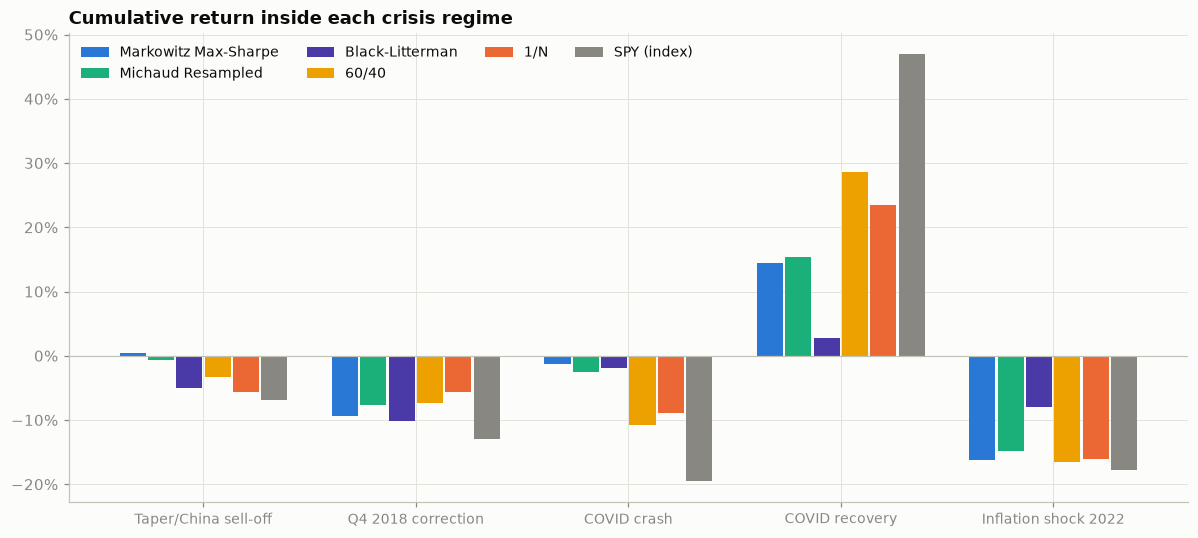

In [4]:
plot_df = regime_total.drop(columns=["Calm markets (ann.)"])
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(plot_df.columns))
n = len(plot_df.index)
width = 0.8 / n
for i, name in enumerate(plot_df.index):
    color = plotting.STRATEGY_COLORS.get(name, "#898781")
    ax.bar(x + (i - n / 2 + 0.5) * width, plot_df.loc[name].values, width * 0.92,
           color=color, label=name)
ax.axhline(0, color="#c3c2b7", lw=0.8)
ax.set_xticks(x, plot_df.columns, fontsize=9)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_title("Cumulative return inside each crisis regime", loc="left")
ax.legend(fontsize=9, ncols=4)
fig.tight_layout()
plotting.savefig(fig, "04_regime_returns")
plt.show()

## 2. Did the crisis hedges earn their place?

For each optimised strategy we track (i) the total weight allocated to the hedge sleeve (TLT, GLD, TIP, DBC) over time, and (ii) the **return contribution** of that sleeve inside each regime ($\sum_{i \in hedges} w_{i,t}\, r_{i,t+1}$, with the target weights applied to the following month — the same convention as the backtest).

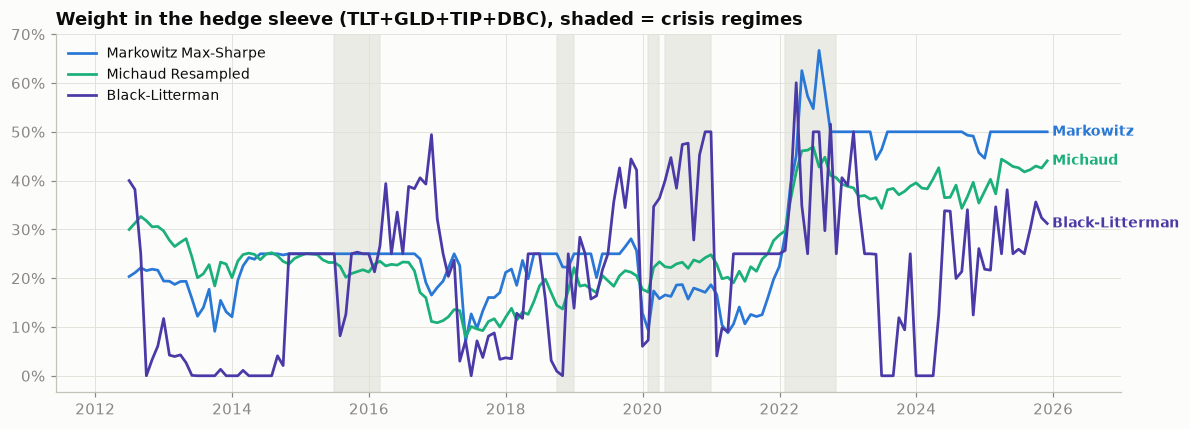

In [5]:
hedges = config.CRISIS_HEDGES
opt_names = ["Markowitz Max-Sharpe", "Michaud Resampled", "Black-Litterman"]

fig, ax = plt.subplots(figsize=(11, 4))
for name in opt_names:
    w_hedge = results[name].weights[hedges].sum(axis=1)
    ax.plot(w_hedge.index, w_hedge.values, color=plotting.STRATEGY_COLORS[name], lw=1.8, label=name)
    ax.annotate(f" {name.split()[0]}", xy=(w_hedge.index[-1], w_hedge.iloc[-1]),
                color=plotting.STRATEGY_COLORS[name], fontsize=9, fontweight="bold", va="center")
for s, e in config.REGIMES.values():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color="#e1e0d9", alpha=0.6)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_title("Weight in the hedge sleeve (TLT+GLD+TIP+DBC), shaded = crisis regimes", loc="left")
ax.legend(fontsize=9, loc="upper left")
ax.margins(x=0.08)
fig.tight_layout()
plotting.savefig(fig, "04_hedge_weights")
plt.show()

In [6]:
def hedge_contribution(res, start, end):
    w = res.weights
    contrib = 0.0
    for t, w_t in w.iterrows():
        nxt = returns.index[returns.index > t]
        if len(nxt) == 0:
            continue
        t1 = nxt[0]
        if pd.Timestamp(start) <= t1 <= pd.Timestamp(end):
            contrib += float((w_t[hedges] * returns.loc[t1, hedges]).sum())
    return contrib

contrib = pd.DataFrame({
    regime: {name: hedge_contribution(results[name], s, e) for name in opt_names}
    for regime, (s, e) in config.REGIMES.items()})
contrib.style.format("{:.2%}").background_gradient(cmap="RdYlGn", axis=None)

,Taper/China sell-off,Q4 2018 correction,COVID crash,COVID recovery,Inflation shock 2022
Markowitz Max-Sharpe,2.21%,0.25%,1.69%,0.60%,-7.97%
Michaud Resampled,1.70%,0.33%,1.87%,1.43%,-6.01%
Black-Litterman,1.94%,-0.95%,2.51%,2.72%,1.21%


Also useful: what did each hedge do *on its own* in each regime? (This separates "the hedge worked" from "the strategy held it".)

In [7]:
hedge_perf = pd.DataFrame({
    regime: (1 + returns.loc[s:e, hedges]).prod() - 1
    for regime, (s, e) in config.REGIMES.items()})
hedge_perf.style.format("{:.2%}").background_gradient(cmap="RdYlGn", axis=None)

,Taper/China sell-off,Q4 2018 correction,COVID crash,COVID recovery,Inflation shock 2022
Ticker,,,,,
TLT,8.79%,1.59%,22.15%,-3.27%,-34.10%
GLD,3.98%,6.82%,3.60%,20.47%,-11.14%
TIP,-0.07%,-1.49%,1.27%,9.45%,-12.69%
DBC,-28.01%,-15.55%,-29.47%,30.67%,20.89%


## 3. Drawdown depth and recovery around the two big shocks

In [8]:
episodes = {"COVID (2020)": ("2020-01-31", "2021-12-31"), "Inflation shock (2022)": ("2022-01-31", "2025-12-31")}
rows = {}
for name, r in oos_returns.items():
    row = {}
    for ep, (s, e) in episodes.items():
        sub = r.loc[s:e]
        row[f"{ep} — max DD"] = metrics.max_drawdown(sub)
        row[f"{ep} — recovery (m)"] = metrics.recovery_months(sub)
    rows[name] = row
pd.DataFrame(rows).T.style.format({c: ("{:.2%}" if "DD" in c else "{:.0f}") for c in rows[name]}, na_rep="not yet")

,COVID (2020) — max DD,COVID (2020) — recovery (m),Inflation shock (2022) — max DD,Inflation shock (2022) — recovery (m)
Markowitz Max-Sharpe,-3.84%,1,-16.51%,10
Michaud Resampled,-4.44%,1,-13.93%,15
Black-Litterman,-4.69%,5,-8.88%,16
60/40,-11.50%,3,-16.75%,15
1/N,-9.27%,3,-15.11%,18
SPY (index),-19.42%,4,-20.25%,9


## 4. Answers to the research question

*Out-of-sample period Jul 2012 – Dec 2025. All figures below are the cumulative returns / contributions computed in the tables above.*

**Q1 — Does the robust machinery earn its value mainly in crises? Yes, and almost entirely as *risk control*, not extra return.**
In **calm markets** the optimised strategies lag the naive ones (annualised: Markowitz 13.0%, Michaud 10.8%, BL 10.3% vs 60/40 14.1% and SPY 21.9%): giving up upside is the price of diversification in a decade-long equity bull market. Their value shows up in the **crisis columns**. In the **COVID crash** SPY fell -19.4% and 60/40 -10.8%, while Markowitz (-1.2%), Michaud (-2.5%) and BL (-1.8%) barely moved — a max-drawdown of ~-4% versus SPY's -19.4%. Between the two robust methods, **Michaud is a smoother Markowitz**: lower drawdown in 4 of the 5 regimes, ~20% less turnover (0.60 vs 0.76 p.a.), at the cost of slightly lower calm-market return. Robustness buys drawdown reduction, not alpha.

**Q2 — Did the crisis hedges deserve their place? Yes — but *which* hedge works is regime-specific, and that is the sharpest result.**
The hedge sleeve did its job in **flight-to-quality** episodes: in the COVID crash TLT returned **+22.1%** and the sleeve added +1.7% to +2.5% across the three strategies. But **2022 breaks the naive hedge story**: long Treasuries lost **-34.1%**, TIPS -12.7% and even gold -11.1% — only commodities (DBC **+20.9%**) protected. As a result the *static* hedge sleeve **hurt** Markowitz (-8.0%) and Michaud (-6.0%) in 2022, because their estimators kept holding the bonds that had been great hedges for a decade. **Only Black–Litterman turned the sleeve positive (+1.2%)**: its 12-1 momentum view had rotated out of bonds and into commodities/energy before the shock, so BL lost just **-7.9%** in 2022 versus ~-16% for everyone else. The hedges earn their place, but capturing the 2022 rotation required an *adaptive* view, not a fixed allocation.

**Q3 — Do the optimised strategies beat the naive benchmarks once regimes are accounted for? On risk, clearly; on raw return in this sample, no.**
By CAGR the naive 60/40 (9.7%) edges Markowitz (8.8%), Michaud (7.4%) and BL (6.2%) — the 2012–2025 US bull market rewarded static equity beta. But on **drawdown control** the optimised strategies dominate exactly when it matters: COVID-crash max drawdown of ~-4% versus -11.5% for 60/40 and -19.4% for SPY, and in 2022 BL's -8.9% versus -16.7% (60/40) and -20.2% (SPY). Whether that trade-off is "value added" depends on the investor's risk tolerance — which is precisely the judgement the assignment asks us to make explicit.

**In one sentence:** robust dynamic allocation did not beat a naive 60/40 on return in a bull market, but it delivered its promise *in the crises* as materially smaller drawdowns — and the single most valuable ingredient was not any fixed "safe" asset (2022 shows Treasuries can fail) but the **regime-reactive view that rotated the hedge**.